In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2.2 Importazione dataset e unione dei dati**

In [2]:
# Importazione delle librerie principali
import pandas as pd

# Caricamento dei file CSV (caricali in Colab o dal tuo Drive)
credits = pd.read_csv('/content/drive/MyDrive/TESI/credits.csv')
keywords = pd.read_csv('/content/drive/MyDrive/TESI/keywords.csv')
links_small = pd.read_csv('/content/drive/MyDrive/TESI/links_small.csv')
movies_metadata = pd.read_csv('/content/drive/MyDrive/TESI/movies_metadata.csv', low_memory=False)

# Estrazione degli ID validi dal file links_small (circa 9000 film)
movie_ids = links_small['tmdbId'].dropna().astype(int).unique()

# Conversione dell'ID in intero per unione coerente
movies_metadata['id'] = pd.to_numeric(movies_metadata['id'], errors='coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors='coerce')
credits['id'] = pd.to_numeric(credits['id'], errors='coerce')

# Filtraggio: teniamo solo i film presenti in links_small
movies_metadata_filtered = movies_metadata[movies_metadata['id'].isin(movie_ids)]
keywords_filtered = keywords[keywords['id'].isin(movie_ids)]
credits_filtered = credits[credits['id'].isin(movie_ids)]

# Unione dei dataset tramite la colonna 'id'
merged_df = movies_metadata_filtered.merge(keywords_filtered, on='id', how='left') \
                                    .merge(credits_filtered, on='id', how='left')

# Selezione delle colonne rilevanti per il content-based filtering
final_movies_df = merged_df[['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]

# Anteprima per verifica
final_movies_df[['id', 'title', 'overview']].head()


,id,title,overview
0,862.0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844.0,Jumanji,When siblings Judy and Peter discover an encha...
2,15602.0,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357.0,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862.0,Father of the Bride Part II,Just when George Banks has recovered from his ...


**2.3 Pulizia dati**

In [3]:
import numpy as np
import ast

# Funzione per estrarre i nomi da colonne JSON (es. genres, keywords)
def estrai_nomi(lista_stringa):
    try:
        lista = ast.literal_eval(lista_stringa)
        return [d['name'] for d in lista if isinstance(d, dict)]
    except (ValueError, SyntaxError):
        return []

# Funzione per estrarre i primi 3 attori
def estrai_attori(lista_stringa):
    try:
        lista = ast.literal_eval(lista_stringa)
        return [d['name'] for d in lista if isinstance(d, dict)][:3]  # primi 3 attori
    except (ValueError, SyntaxError):
        return []

# Funzione per estrarre il regista
def estrai_regista(lista_stringa):
    try:
        lista = ast.literal_eval(lista_stringa)
        for d in lista:
            if isinstance(d, dict) and d.get('job') == 'Director':
                return d['name']
        return np.nan
    except (ValueError, SyntaxError):
        return np.nan

# Applichiamo le funzioni di pulizia alle colonne del DataFrame
final_movies_df['genres'] = final_movies_df['genres'].apply(estrai_nomi)
final_movies_df['keywords'] = final_movies_df['keywords'].apply(estrai_nomi)
final_movies_df['cast'] = final_movies_df['cast'].apply(estrai_attori)
final_movies_df['director'] = final_movies_df['crew'].apply(estrai_regista)

# Manteniamo solo le colonne finali utili
final_movies_df = final_movies_df[['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'director']]

# Controllo: visualizziamo un campione dei dati puliti
final_movies_df.head()


<ipython-input-3-0d7c73c97343>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_movies_df['genres'] = final_movies_df['genres'].apply(estrai_nomi)
<ipython-input-3-0d7c73c97343>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_movies_df['keywords'] = final_movies_df['keywords'].apply(estrai_nomi)
<ipython-input-3-0d7c73c97343>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

,id,title,overview,genres,keywords,cast,director
0,862.0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter
1,8844.0,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston
2,15602.0,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch
3,31357.0,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]","[based on novel, interracial relationship, sin...","[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker
4,11862.0,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],"[baby, midlife crisis, confidence, aging, daug...","[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer


**2.4 Esplorazione dei Dati (EDA)**

Numero totale di film: 9219
Lunghezza media delle overview: 52.64410456665582


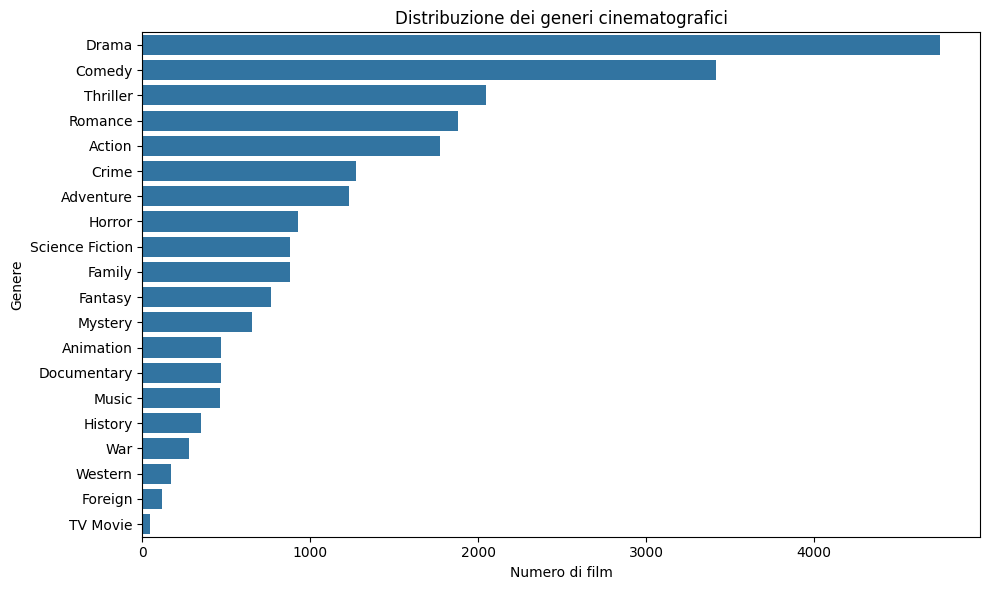

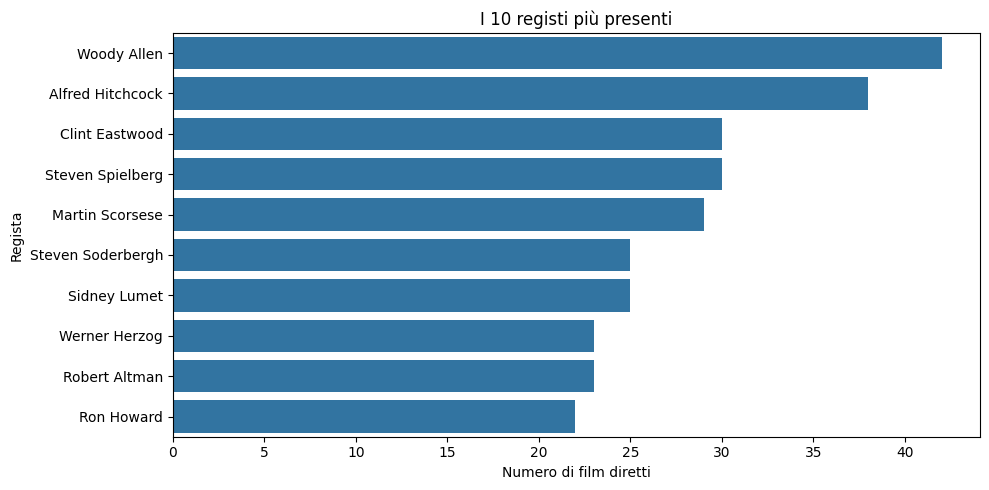

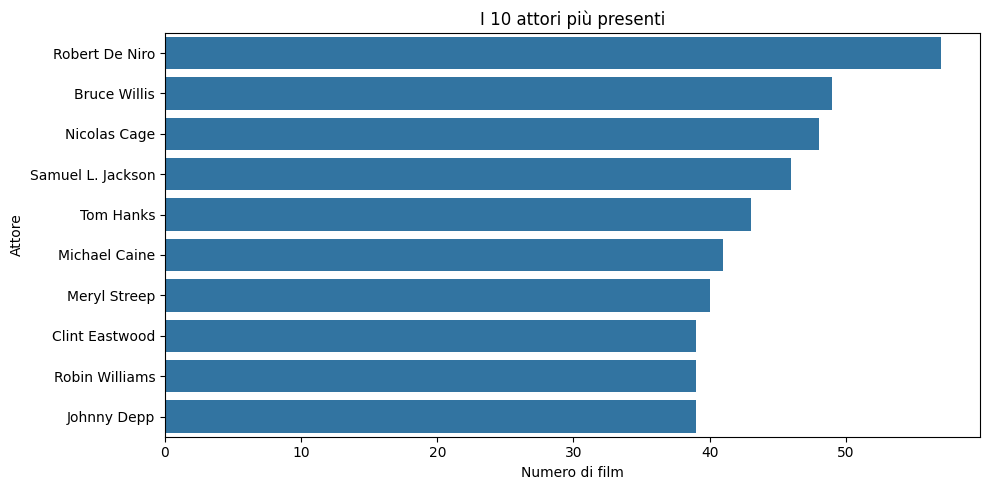

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supponiamo di avere il DataFrame 'final_movies_df' già pulito

# 1. Contare quanti film abbiamo
print("Numero totale di film:", final_movies_df.shape[0])

# 2. Statistiche sulla lunghezza delle trame (overview)
final_movies_df['overview_length'] = final_movies_df['overview'].apply(lambda x: len(str(x).split()))
print("Lunghezza media delle overview:", final_movies_df['overview_length'].mean())

# 3. Analizzare i generi
# Creiamo una lista unica di tutti i generi
all_genres = final_movies_df['genres'].explode()
genres_count = all_genres.value_counts()

# Visualizzare i generi più popolari
plt.figure(figsize=(10,6))
sns.barplot(x=genres_count.values, y=genres_count.index)
plt.title('Distribuzione dei generi cinematografici')
plt.xlabel('Numero di film')
plt.ylabel('Genere')
plt.tight_layout()
plt.show()

# 4. Analizzare i registi più presenti (top 10)
top_directors = final_movies_df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title('I 10 registi più presenti')
plt.xlabel('Numero di film diretti')
plt.ylabel('Regista')
plt.tight_layout()
plt.show()

# 5. Analizzare gli attori più presenti (opzionale)
all_cast = final_movies_df['cast'].explode()
top_actors = all_cast.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title('I 10 attori più presenti')
plt.xlabel('Numero di film')
plt.ylabel('Attore')
plt.tight_layout()
plt.show()


**3.3 Pre Processing testuale**

In [5]:
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('all', halt_on_error=False)



# Inizializzazione degli strumenti
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Funzione per mappare i tag POS di NLTK a quelli di WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

# Funzione per unire overview, generi, parole chiave, cast e regista
def crea_testo_completo(row):
    elementi = []
    for campo in ['overview', 'genres', 'keywords', 'cast', 'director']:
        valore = row[campo]
        if isinstance(valore, list):
            elementi += valore
        elif isinstance(valore, str):
            elementi.append(valore)
    return ' '.join(elementi)

# Funzione di pulizia avanzata con POS-aware lemmatizzazione
def pulisci_testo_avanzata(testo):
    testo = testo.lower()  # Convertiamo tutto in minuscolo
    testo = re.sub(r"'s\b", '', testo)  # Rimuoviamo il possessivo ('s)
    testo = re.sub(r'[^a-z\s]', '', testo)  # Rimuoviamo punteggiatura, numeri, simboli
    parole = nltk.word_tokenize(testo)  # Tokenizzazione
    parole_filtrate = [w for w in parole if w not in stop_words]  # Rimuoviamo le stopwords
    pos_tags = pos_tag(parole_filtrate)  # POS tagging
    parole_lem = [lemmatizer.lemmatize(w, pos='v') for w in parole_filtrate]  # Lemmatizzazione forzata come verbo
    return ' '.join(parole_lem)


# Applichiamo il preprocessing
final_movies_df['testo_completo'] = final_movies_df.apply(crea_testo_completo, axis=1)
final_movies_df['testo_pulito'] = final_movies_df['testo_completo'].apply(pulisci_testo_avanzata)

# Anteprima del risultato
final_movies_df[['title', 'testo_pulito']].head()




[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

,title,testo_pulito
0,Toy Story,lead woody andy toy live happily room andy bir...
1,Jumanji,siblings judy peter discover enchant board gam...
2,Grumpier Old Men,family wed reignite ancient feud nextdoor neig...
3,Waiting to Exhale,cheat mistreat step women hold breath wait elu...
4,Father of the Bride Part II,george bank recover daughter wed receive news ...


**3.4 TF-IDF + Cosine Similarity (con n-grams)**

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Costruzione della matrice TF-IDF con n-grams (unigrammi + bigrammi)
tfidf = TfidfVectorizer(ngram_range=(1, 2))  # Usa sia parole singole che coppie
tfidf_matrix = tfidf.fit_transform(final_movies_df['testo_pulito'])

# Calcolo della similarità coseno tra tutti i film
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Creazione di una Serie con gli indici per titolo
indices = pd.Series(final_movies_df.index, index=final_movies_df['title']).drop_duplicates()

# Funzione per ottenere raccomandazioni dato un titolo
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]  # esclude il film stesso e prende i 5 più simili
    film_indices = [i[0] for i in sim_scores]
    return final_movies_df[['title', 'overview']].iloc[film_indices]

# Esempio di raccomandazioni
get_recommendations('Toy Story')


,title,overview
2514,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy..."
7589,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven..."
1492,Small Soldiers,When missile technology is used to enhance toy...
8479,Toy Story of Terror!,What starts out as a fun road trip for the Toy...
1789,Toys,Leslie Zevo is a fun-loving inventor who must ...


**3.5 CountVectorizer + Cosine Similarity**

In [7]:
from sklearn.feature_extraction.text import CountVectorizer


# 1. Creazione della matrice CountVectorizer con unigrammi e bigrammi
count = CountVectorizer(ngram_range=(1, 2))  # Usa unigrams e bigrams
count_matrix = count.fit_transform(final_movies_df['testo_pulito'])

# 2. Calcolo della similarità coseno
cosine_sim_count = cosine_similarity(count_matrix, count_matrix)

# 3. Serie per indicizzare i film tramite il titolo
indices = pd.Series(final_movies_df.index, index=final_movies_df['title']).drop_duplicates()

# 4. Funzione di raccomandazione per titolo
def get_recommendations_count(title, cosine_sim=cosine_sim_count):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]  # esclude il film stesso
    film_indices = [i[0] for i in sim_scores]
    return final_movies_df[['title', 'overview']].iloc[film_indices]

# 5. Esecuzione esempio per "Toy Story"
get_recommendations_count('Toy Story')


,title,overview
2514,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy..."
7589,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven..."
1492,Small Soldiers,When missile technology is used to enhance toy...
8479,Toy Story of Terror!,What starts out as a fun road trip for the Toy...
1563,Child's Play 2,Chuckie's back as the doll possessed by the so...


**3.6 Word2Vec + Cosine Similarity**

In [8]:
#!pip install numpy==1.23.5 --force-reinstall

In [9]:
#!pip install gensim --upgrade --force-reinstall

In [10]:
import gensim.downloader as api
from gensim.models import KeyedVectors

# Caricamento modello pre-addestrato Word2Vec (Google News 300D)
#w2v_model = api.load("word2vec-google-news-300") # (primo download)
#w2v_model.save("/content/drive/MyDrive/TESI/word2vec-google-news-300.kv")
w2v_model = KeyedVectors.load("/content/drive/MyDrive/TESI/word2vec-google-news-300.kv") #carica dal drive

# Funzione per convertire un documento (film) in vettore medio
def document_vector(doc):
    words = doc.split()
    words = [w for w in words if w in w2v_model]
    if len(words) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model[words], axis=0)

# Creiamo i vettori medi per ogni film
movie_vectors = final_movies_df['testo_pulito'].apply(document_vector)
movie_matrix = np.vstack(movie_vectors.values)

# Similarità coseno tra film
cosine_sim_w2v = cosine_similarity(movie_matrix, movie_matrix)

# Indicizzazione per titolo
indices = pd.Series(final_movies_df.index, index=final_movies_df['title']).drop_duplicates()

# Funzione di raccomandazione con Word2Vec
def get_recommendations_w2v(title, cosine_sim=cosine_sim_w2v):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]
    film_indices = [i[0] for i in sim_scores]
    return final_movies_df[['title', 'overview']].iloc[film_indices]

# Esempio per "Toy Story"
get_recommendations_w2v("Toy Story")


,title,overview
7589,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven..."
2514,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy..."
2250,Big,"A young boy, Josh Baskin makes a wish at a car..."
3125,Urbania,Charlie takes an odyssey through grief during ...
5854,Dominick and Eugene,"Dominick and Eugene are twins, but Dominick is..."


**3.7 BERT + cosine similarity**

In [11]:
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer

# Caricamento del modello BERT pre-addestrato
#model_bert = SentenceTransformer('all-MiniLM-L6-v2')  # veloce e preciso
#model_bert.save('/content/drive/MyDrive/TESI/bert_models/all-MiniLM-L6-v2')
model_bert = SentenceTransformer('/content/drive/MyDrive/TESI/bert_models/all-MiniLM-L6-v2')

# Creazione vettori embedding per ogni film
# Usiamo direttamente il testo pre-elaborato (testo_pulito)
corpus = final_movies_df['testo_pulito'].tolist()
embeddings_bert = model_bert.encode(corpus, convert_to_tensor=True, show_progress_bar=True)

# Calcolo della similarità coseno
cosine_sim_bert = cosine_similarity(embeddings_bert)

# Serie per indicizzazione
indices = pd.Series(final_movies_df.index, index=final_movies_df['title']).drop_duplicates()

# Funzione per raccomandazioni basate su BERT
def get_recommendations_bert(title, cosine_sim=cosine_sim_bert):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]
    film_indices = [i[0] for i in sim_scores]
    return final_movies_df[['title', 'overview']].iloc[film_indices]

# Esecuzione: otteniamo raccomandazioni per "Toy Story"
get_recommendations_bert("Toy Story")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 823.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 453.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 807.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 973.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

Batches:   0%|          | 0/289 [00:00<?, ?it/s]

,title,overview
7589,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven..."
2514,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy..."
2250,Big,"A young boy, Josh Baskin makes a wish at a car..."
3042,Chuck & Buck,Buck is a man-child who has lived his existenc...
8479,Toy Story of Terror!,What starts out as a fun road trip for the Toy...


**3.9 Modello selezionato: BERT (funzione finale)**

In [12]:
final_movies_df[final_movies_df['title'].str.contains("Jumanji", case=False, na=False)]\
    .reset_index()[['index', 'title']].head(10)


,index,title
0,1,Jumanji


In [13]:
# Funzione ufficiale di raccomandazione finale basata su BERT
def get_final_recommendations(title, cosine_sim=cosine_sim_bert):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]  # Esclude il film stesso
    film_indices = [i[0] for i in sim_scores]
    return final_movies_df[['title', 'overview']].iloc[film_indices]

# Esempio: raccomandazioni finali
get_final_recommendations("Jumanji")


,title,overview
6335,"The Chronicles of Narnia: The Lion, the Witch ...","Siblings Lucy, Edmund, Susan and Peter step th..."
6923,The Spiderwick Chronicles,Upon moving into the run-down Spiderwick Estat...
2546,Stuart Little,The adventures of a heroic and debonair stalwa...
567,James and the Giant Peach,When the young orphan boy James spills a magic...
6686,The Last Mimzy,Two siblings begin to develop special talents ...


**4.2 Caricamento dataset e matrice utente-film**

In [14]:
ratings = pd.read_csv('/content/drive/MyDrive/TESI/ratings_small.csv')
links = pd.read_csv('/content/drive/MyDrive/TESI/links_small.csv')

# 2. Conversione degli ID
links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce')
movies_metadata['id'] = pd.to_numeric(movies_metadata['id'], errors='coerce')

# 3. Merge links + metadata → otteniamo titolo da movieId
id_map = links.merge(movies_metadata[['id', 'title']], left_on='tmdbId', right_on='id')
id_map = id_map[['movieId', 'title']]

# 4. Uniamo i titoli al dataset delle valutazioni
ratings = ratings.merge(id_map, on='movieId')

# 5. Creiamo la matrice utente-film (userId x titolo)
user_item_matrix = ratings.pivot_table(index='userId', columns='title', values='rating')


In [15]:
# Mostra le colonne (film) con più valutazioni
most_rated_movies = user_item_matrix.count().sort_values(ascending=False).head(5).index

# Mostra gli utenti che hanno votato almeno uno di questi film
rows_with_values = user_item_matrix[most_rated_movies].dropna(how='all').head()

# Visualizza
rows_with_values



title,Forrest Gump,Pulp Fiction,The Shawshank Redemption,The Silence of the Lambs,Star Wars
userId,,,,,
2,3.0,4.0,NaN,3.0,NaN
3,5.0,4.5,5.0,3.0,NaN
4,5.0,5.0,NaN,NaN,5.0
5,4.0,NaN,NaN,NaN,NaN
7,3.0,NaN,5.0,NaN,5.0


**4.3 SVD**

In [16]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2461556 sha256=60fb122677b0fc806a8840ab4ab1832ac9220734f741f4a6008d883921c57c08
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [17]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, KFold

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# 2. Inizializzazione del modello con seme fisso
svd = SVD(random_state=42)

# 3. KFold deterministico (shuffle=True con random_state)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Cross-validation stabile e ripetibile
cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=kf, verbose=True)



Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8891  0.9034  0.8999  0.9035  0.8937  0.8979  0.0057  
MAE (testset)     0.6826  0.6964  0.6946  0.6960  0.6870  0.6913  0.0055  
Fit time          4.83    2.95    3.19    2.77    5.05    3.76    0.98    
Test time         0.41    0.23    0.22    0.44    0.35    0.33    0.09    


{'test_rmse': array([0.88914405, 0.90338973, 0.89989072, 0.90354466, 0.89368612]),
 'test_mae': array([0.68263541, 0.69637074, 0.69463759, 0.69604636, 0.68703402]),
 'fit_time': (4.832304239273071,
  2.952516555786133,
  3.190670967102051,
  2.77296781539917,
  5.047173738479614),
 'test_time': (0.4139883518218994,
  0.22516274452209473,
  0.22281455993652344,
  0.44349122047424316,
  0.3510317802429199)}

In [18]:
# 1. Addestramento SVD su tutto il dataset
trainset = data.build_full_trainset()
svd.fit(trainset)

# 2. Costruisci il dizionario movieId → titolo (una volta sola)
movieId_to_title = id_map.set_index('movieId')['title'].to_dict()

# 3. Funzione per ottenere le predizioni su richiesta
def get_model_predictions(model, user_id, movie_ids, movieId_to_title):
    results = []
    for mid in movie_ids:
        pred = model.predict(user_id, mid)
        title = movieId_to_title.get(mid, "Titolo sconosciuto")
        results.append((title, round(pred.est, 2)))
    return results

# 4. Esempio di utilizzo con 5 film selezionati
user_id = 100
movie_ids = [1, 296, 318, 356, 527]  # Toy Story, Pulp Fiction, Shawshank, Forrest Gump, Schindler's List

predicted_ratings = get_model_predictions(svd, user_id, movie_ids, movieId_to_title)

# 5. Stampa dei risultati
print(f"\nRating stimati per l'utente {user_id} usando SVD:\n")
for title, rating in predicted_ratings:
    print(f"{title} → {rating}")



Rating stimati per l'utente 100 usando SVD:

Toy Story → 3.82
Pulp Fiction → 4.39
The Shawshank Redemption → 4.29
Forrest Gump → 3.56
Schindler's List → 4.47


**4.4 KNN user-based**

In [19]:
from surprise import KNNBasic

# opzioni di similarità per user-based (coseno)
sim_options = {
    'name': 'cosine',
    'user_based': True
}

# Inizializzazione modello KNN user-based
knn_user = KNNBasic(sim_options=sim_options)


In [20]:
# Costruzione del dataset
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# KFold deterministico
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation
cross_validate(knn_user, data, measures=['RMSE', 'MAE'], cv=kf, verbose=True)


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9892  1.0017  0.9937  0.9986  0.9869  0.9940  0.0055  
MAE (testset)     0.7642  0.7741  0.7671  0.7716  0.7615  0.7677  0.0046  
Fit time          0.41    1.13    0.41    0.80    0.87    0.73    0.28    
Test time         5.57    4.40    3.34    5.87    3.18    4.47    1.11    


{'test_rmse': array([0.98917055, 1.00166983, 0.99367973, 0.99860178, 0.9869491 ]),
 'test_mae': array([0.76424899, 0.77414269, 0.76712325, 0.77155064, 0.76150434]),
 'fit_time': (0.414231538772583,
  1.1334154605865479,
  0.4094414710998535,
  0.8008830547332764,
  0.8744983673095703),
 'test_time': (5.574542284011841,
  4.398292303085327,
  3.3371365070343018,
  5.8662943840026855,
  3.1812262535095215)}

In [21]:
# Addestramento su tutto il dataset
trainset = data.build_full_trainset()
knn_user.fit(trainset)

# Lista dei 5 movieId fissi
movie_ids = [1, 296, 318, 356, 527]  # Toy Story, Pulp Fiction, Shawshank, Forrest Gump, Schindler's List
user_id = 100

# predizioni
predicted_ratings_knn = get_model_predictions(knn_user, user_id, movie_ids, movieId_to_title)

# Stampa i risultati
print(f"\nRating stimati (KNN user-based) per l'utente {user_id}:\n")
for title, rating in predicted_ratings_knn:
    print(f"{title} → {rating}")


Computing the cosine similarity matrix...
Done computing similarity matrix.

Rating stimati (KNN user-based) per l'utente 100:

Toy Story → 4.02
Pulp Fiction → 4.29
The Shawshank Redemption → 4.44
Forrest Gump → 4.26
Schindler's List → 4.16


**5.2 approccio score-based**

In [22]:
from sklearn.preprocessing import MinMaxScaler

# Funzione per ottenere gli score BERT per un film
def get_bert_scores(title, sim_matrix, df):
    idx = df[df['title'] == title].index[0]
    scores = list(enumerate(sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [(df.iloc[i]['title'], score) for i, score in scores if df.iloc[i]['title'] != title]

# Funzione principale per fusione score-based
def hybrid_score_based(user_id, title_input, top_n=10, alpha=0.5):
    # 1. Recupera score da BERT
    bert_scores = get_bert_scores(title_input, cosine_sim_bert, final_movies_df)

    # 2. Prepara le due liste di punteggi
    titles = []
    bert_vals = []
    svd_vals = []

    for title, bert_score in bert_scores:
        # Ottieni movieId per predizione SVD
        try:
            movie_id = id_map[id_map['title'] == title]['movieId'].values[0]
        except:
            continue
        try:
            svd_score = svd.predict(user_id, movie_id).est
        except:
            continue
        titles.append(title)
        bert_vals.append(bert_score)
        svd_vals.append(svd_score)

    # 3. Normalizzazione con MinMaxScaler
    scaler = MinMaxScaler()
    bert_norm = scaler.fit_transform(np.array(bert_vals).reshape(-1, 1)).flatten()
    svd_norm = scaler.fit_transform(np.array(svd_vals).reshape(-1, 1)).flatten()

    # 4. Fusione score
    hybrid_scores = alpha * bert_norm + (1 - alpha) * svd_norm

    # 5. Output ordinato
    results = list(zip(titles, hybrid_scores))
    results = sorted(results, key=lambda x: x[1], reverse=True)

    return results[:top_n]


**Esempio di raccomadazione**



In [23]:
# Peso pari
print("α = 0.5 — Utente 100:")
recs_07_u100 = hybrid_score_based(user_id=100, title_input="Toy Story", top_n=10, alpha=0.5)
for title, score in recs_07_u100:
    print(f"{title} — Score: {round(score, 4)}")

print("\nα = 0.5 — Utente 250:")
recs_07_u250 = hybrid_score_based(user_id=250, title_input="Toy Story", top_n=10, alpha=0.5)
for title, score in recs_07_u250:
    print(f"{title} — Score: {round(score, 4)}")


α = 0.5 — Utente 100:
Toy Story 3 — Score: 0.9373
Toy Story 2 — Score: 0.8817
Big — Score: 0.7767
Annie Hall — Score: 0.7754
Sleeper — Score: 0.7687
Harvey — Score: 0.7665
About Time — Score: 0.7629
Raging Bull — Score: 0.7558
Swingers — Score: 0.7524
Big Hero 6 — Score: 0.7466

α = 0.5 — Utente 250:
Toy Story 3 — Score: 0.8992
Toy Story 2 — Score: 0.8667
Big — Score: 0.7925
Harvey — Score: 0.7881
Big Hero 6 — Score: 0.7618
The Shawshank Redemption — Score: 0.7551
Midnight in Paris — Score: 0.7489
Gladiator 1992 — Score: 0.7484
Swingers — Score: 0.7477
On the Waterfront — Score: 0.741


**5.3 Approccio sequenziale**

In [24]:
# 1. Funzione per ottenere i titoli raccomandati da BERT (content-based)
def get_top_similar_titles_bert(title_input, top_n, cosine_sim_matrix, df, index_series):
    idx = index_series[title_input]
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]  # esclude se stesso
    indices = [i[0] for i in sim_scores]
    return df.iloc[indices]['title'].tolist()

# 2. Funzione per valutare con SVD i film raccomandati da BERT
def sequential_hybrid(user_id, title_input, top_n, cosine_sim_matrix, df, index_series, model, id_map):
    # Step 1: Raccomandazioni content-based (BERT)
    candidate_titles = get_top_similar_titles_bert(title_input, top_n, cosine_sim_matrix, df, index_series)

    # Step 2: Previsione dei rating collaborativi (SVD)
    movieId_map = id_map.set_index('title')['movieId'].to_dict()

    predictions = []
    for title in candidate_titles:
        movie_id = movieId_map.get(title)
        if movie_id:
            pred = model.predict(user_id, movie_id)
            predictions.append((title, round(pred.est, 2)))

    # Step 3: Ordina per rating predetto
    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    return sorted_predictions


In [25]:
# Esegui per utente 100
result_seq_100 = sequential_hybrid(
    user_id=100,
    title_input="Toy Story",
    top_n=10,
    cosine_sim_matrix=cosine_sim_bert,
    df=final_movies_df,
    index_series=indices,
    model=svd,
    id_map=id_map
)

# Esegui per utente 250
result_seq_250 = sequential_hybrid(
    user_id=250,
    title_input="Toy Story",
    top_n=10,
    cosine_sim_matrix=cosine_sim_bert,
    df=final_movies_df,
    index_series=indices,
    model=svd,
    id_map=id_map
)

# Stampa risultati
print("Utente 100 – Approccio sequenziale:")
for title, score in result_seq_100:
    print(f"{title} → {score}")

print("\nUtente 250 – Approccio sequenziale:")
for title, score in result_seq_250:
    print(f"{title} → {score}")


Utente 100 – Approccio sequenziale:
Toy Story 3 → 4.13
Toy Story 2 → 3.83
Big → 3.74
Robot & Frank → 3.46
Husbands and Wives → 3.46
Chuck & Buck → 3.41
Toy Story of Terror! → 3.4
The Rugrats Movie → 3.2
Trees Lounge → 3.16
American Pie 2 → 3.03

Utente 250 – Approccio sequenziale:
Toy Story 3 → 4.47
Big → 4.38
Toy Story 2 → 4.31
Chuck & Buck → 4.18
Husbands and Wives → 4.16
Robot & Frank → 4.13
Toy Story of Terror! → 4.03
The Rugrats Movie → 3.91
Trees Lounge → 3.73
American Pie 2 → 3.4


 **5.5 Confronto quantitativo**

5 film da nascondere

In [26]:
import random

user_id = 100

ratings['movieId'] = ratings['movieId'].astype(int)
id_map['movieId'] = id_map['movieId'].astype(int)

# Valutazioni dell’utente
user_ratings = ratings[ratings['userId'] == user_id]

# 5 film a caso da nascondere
hidden_movies = random.sample(list(user_ratings['movieId'].unique()), 5)

hidden_df = user_ratings[user_ratings['movieId'].isin(hidden_movies)].merge(id_map, on='movieId', how='left')
hidden_df = hidden_df.rename(columns={'title_y': 'title'})
print("Film da nascondere:")
print(hidden_df[['movieId', 'title', 'rating']].drop_duplicates())


Film da nascondere:
   movieId                                title  rating
0        1                            Toy Story     4.0
1       52                     Mighty Aphrodite     3.0
2       62                   Mr. Holland's Opus     3.0
3       86                         White Squall     3.0
4     1073  Willy Wonka & the Chocolate Factory     5.0


Funzioni dei due approcci

In [27]:
hidden_df['title'] = hidden_df['title'].str.lower().str.strip()
id_map['title'] = id_map['title'].str.lower().str.strip()
final_movies_df['title'] = final_movies_df['title'].str.lower().str.strip()

In [28]:
# Film valutati da user 100 che hanno titolo disponibile
user_100_movies = ratings[ratings['userId'] == 100].merge(id_map, on='movieId', how='inner')
user_100_movies = user_100_movies.rename(columns={'title_y': 'title'})
user_100_movies = user_100_movies[['movieId', 'title', 'rating']].drop_duplicates()

# Normalizzo titolo
user_100_movies['title'] = user_100_movies['title'].str.lower().str.strip()

# Mostro tutti quelli validi
print(user_100_movies.sort_values('title').head(20))


    movieId                        title  rating
19      745                a close shave     4.0
9        88                  black sheep     2.0
10       95                 broken arrow     3.0
11      135               down periscope     3.0
21      786                       eraser     3.0
13      608                        fargo     4.0
1         3             grumpier old men     4.0
2         6                         heat     3.0
20      780             independence day     3.0
15      661    james and the giant peach     3.0
4        25            leaving las vegas     4.0
6        52             mighty aphrodite     3.0
14      648          mission: impossible     3.0
7        62           mr. holland's opus     3.0
22      802                   phenomenon     4.0
3         7                      sabrina     3.0
24     1356     star trek: first contact     4.0
12      141                 the birdcage     3.0
17      733                     the rock     3.0
16      708  the tru

In [29]:
hidden_movies = [3, 88, 648, 141, 1356]

user_id = 100
user_ratings = ratings[ratings['userId'] == user_id]

hidden_df = user_ratings[user_ratings['movieId'].isin(hidden_movies)].merge(id_map, on='movieId', how='left')
hidden_df = hidden_df.rename(columns={'title_y': 'title'}) if 'title_y' in hidden_df.columns else hidden_df
hidden_df['title'] = hidden_df['title'].str.lower().str.strip()

# Visualizza
print("Ground truth finale aggiornato:")
print(hidden_df[['movieId', 'title', 'rating']])


Ground truth finale aggiornato:
   movieId                     title  rating
0        3          grumpier old men     4.0
1       88               black sheep     2.0
2      141              the birdcage     3.0
3      648       mission: impossible     3.0
4     1356  star trek: first contact     4.0


In [30]:
def get_bert_scores_safe(title, sim_matrix, df):
    title = title.lower().strip()
    try:
        idx = df[df['title'].str.lower().str.strip() == title].index[0]
    except IndexError:
        return []
    scores = list(enumerate(sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [(df.iloc[i]['title'], score) for i, score in scores if df.iloc[i]['title'].lower().strip() != title]


In [31]:
# Score-Based

def predict_score_based(user_id, movie_id, alpha=0.5):
    try:
        title = id_map[id_map['movieId'] == movie_id]['title'].values[0].lower().strip()
        bert_scores = get_bert_scores_safe(title, cosine_sim_bert, final_movies_df)
        if not bert_scores:
            return np.nan

        bert_vals   = list(dict(bert_scores).values())
        score_bert  = np.mean(bert_vals)                       # 0‒1
        score_svd   = svd.predict(user_id, movie_id).est       # 0.5‒5

        # normalizza entrambi su 0‒1
        score_bert_n = (score_bert - min(bert_vals)) / (max(bert_vals) - min(bert_vals))
        score_svd_n  = (score_svd  - 0.5) / 4.5

        score_norm   = alpha * score_svd_n + (1 - alpha) * score_bert_n
        return score_norm * 4.5 + 0.5                          # torna a scala rating
    except:
        return np.nan

# Sequenziale

def predict_sequenziale(user_id, movie_id, beta=0.7):
    """
    beta = 0.7  → 70 % del punteggio SVD  + 30 % dal contenuto
    """
    try:
        title = id_map[id_map['movieId'] == movie_id]['title'].values[0].lower().strip()
        if title not in final_movies_df['title'].values:
            return np.nan

        bert_scores = get_bert_scores_safe(title, cosine_sim_bert, final_movies_df)
        if not bert_scores:
            return np.nan

        score_bert = np.mean(list(dict(bert_scores).values())) * 5    # scala a 0.5‒5
        score_svd  = svd.predict(user_id, movie_id).est               # già 0.5‒5

        # Fusione pesata e clamp a [0.5, 5.0]
        rating = beta * score_svd + (1 - beta) * score_bert
        return max(0.5, min(5.0, rating))
    except:
        return np.nan


Previsioni

In [32]:
true_ratings = []
pred_score = []
pred_seq = []

for _, row in hidden_df.iterrows():
    movie_id = row['movieId']
    true_rating = row['rating']
    title = row['title']

    # Score-Based
    try:
        r_sb = predict_score_based(user_id, movie_id, alpha=0.5)
    except:
        r_sb = np.nan

    # Sequenziale
    try:
        r_seq = predict_sequenziale(user_id, movie_id)
    except:
        r_seq = np.nan

    true_ratings.append(true_rating)
    pred_score.append(r_sb)
    pred_seq.append(r_seq)


Metriche

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Tieni solo i valori validi
valid_idx = [i for i in range(len(true_ratings)) if not np.isnan(pred_score[i]) and not np.isnan(pred_seq[i])]

y_true = [true_ratings[i] for i in valid_idx]
y_sb = [pred_score[i] for i in valid_idx]
y_seq = [pred_seq[i] for i in valid_idx]

# Calcolo RMSE / MAE
rmse_sb = mean_squared_error(y_true, y_sb) ** 0.5
mae_sb = mean_absolute_error(y_true, y_sb)

rmse_seq = mean_squared_error(y_true, y_seq) ** 0.5
mae_seq = mean_absolute_error(y_true, y_seq)

# Risultato finale
print("Risultati quantitativi — Confronto finale:")
print("Score-Based → RMSE:", round(rmse_sb, 4), "| MAE:", round(mae_sb, 4))
print("Sequenziale → RMSE:", round(rmse_seq, 4), "| MAE:", round(mae_seq, 4))


Risultati quantitativi — Confronto finale:
Score-Based → RMSE: 0.768 | MAE: 0.6475
Sequenziale → RMSE: 0.7497 | MAE: 0.6582


In [34]:
# Tabella di confronto
titoli_val = [hidden_df.iloc[i]['title'] for i in valid_idx]

df_confronto = pd.DataFrame({
    "Titolo": titoli_val,
    "Rating reale": y_true,
    "Predizione Score-Based": [round(r, 2) for r in y_sb],
    "Predizione Sequenziale": [round(r, 2) for r in y_seq]
})

from IPython.display import display
display(df_confronto)


,Titolo,Rating reale,Predizione Score-Based,Predizione Sequenziale
0,grumpier old men,4.0,2.89,2.84
1,black sheep,2.0,2.79,2.30
2,the birdcage,3.0,2.93,2.66
3,mission: impossible,3.0,2.75,2.53
4,star trek: first contact,4.0,2.99,2.98


In [35]:
import joblib, pickle, numpy as np
import pandas as pd, os, json

SAVE_DIR = '/content/drive/MyDrive/TESI/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Modello collaborativo SVD
joblib.dump(svd, f'{SAVE_DIR}/svd.pkl')

# 2. Matrice di similarità BERT
np.save(f'{SAVE_DIR}/cosine_sim_bert.npy', cosine_sim_bert)

# 3. DataFrame film + testi
final_movies_df.to_pickle(f'{SAVE_DIR}/final_movies_df.pkl')

# 4. Mapping movieId → title (serve al backend)
id_map.to_pickle(f'{SAVE_DIR}/id_map.pkl')

# 5. Parametri di default (alpha, ecc.) in JSON
with open(f'{SAVE_DIR}/config.json', 'w') as fp:
    json.dump({"alpha_default": 0.5}, fp)

print("✅ Oggetti salvati in:", SAVE_DIR)


✅ Oggetti salvati in: /content/drive/MyDrive/TESI/models
